In [29]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("cleaned_data.csv")


In [ ]:

# FEATURES
df["exercise"] = df["Did Physical activity/Exercises/Gym improve your health condition"].astype(str).str.contains("Yes", na=False).astype(int)

df["diet"] = df["Did diet and eating habits improve your Health condition"].astype(str).str.contains("Yes", na=False).astype(int)

df["treatment"] = df["Did medical and physical treatment improve your health?"].astype(str).str.contains("Yes", na=False).astype(int)

df["stress"] = pd.to_numeric(df["Stress level"], errors="coerce").fillna(0)

X = df[["exercise", "diet", "treatment", "stress"]]

In [26]:
# CLUSTERING
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

df["cluster"] = labels

c:\Users\joshi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [27]:
# PCA
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

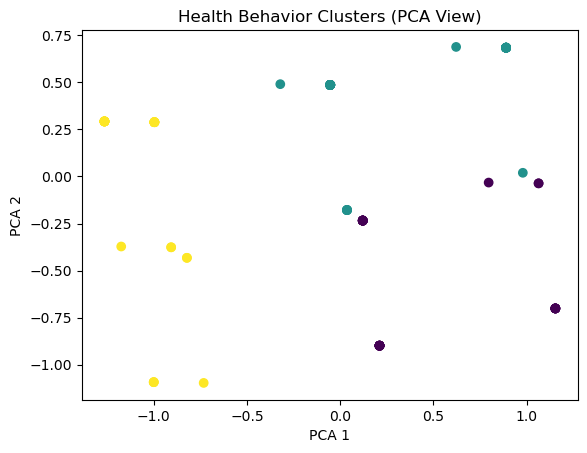

In [28]:
# PLOT
plt.scatter(X_2d[:,0], X_2d[:,1], c=df["cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Health Behavior Clusters (PCA View)")
plt.show()